# Notebook 50: Advanced ML Exploration - XGBoost SHAP & Isolation Forests

In this notebook, we deploy advanced machine learning techniques to decode the *mechanisms* and *anomalies* of the Italian Educational Equilibrium.
1. **Explainable AI (XGBoost + SHAP):** Predicting regional/provincial educational outcomes (track diversity and supply) and extracting precise feature attributions.
2. **Anomaly Detection (Isolation Forest):** Identifying systemic outliers—municipalities that break the OED pipeline rules.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import xgboost as xgb
import shap
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 30)
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 120

ROOT = Path('c:/Users/Dell/Documents/Antigravity/Italienation').resolve()
PROC = ROOT / 'local_data/processed'


---
## 1. XGBoost & SHAP: Predicting the Technical Divide
We will predict the prevalence of Technical/Vocational tracks in a province using our socio-economic and structural vectors. Then we use SHAP to explain the model.


XGBoost R^2 Score: -0.356


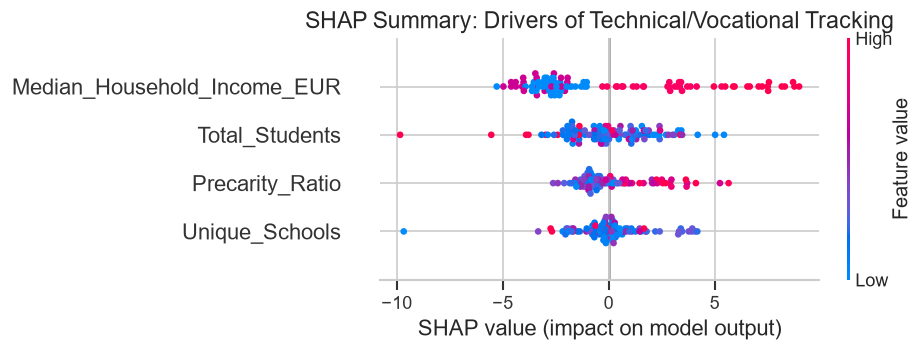

In [2]:
# Load structural data
students = pd.read_parquet(ROOT / 'local_data/UNICA/hf_students_upper_sec_stat_2024_25.parquet')
scuole = pd.read_parquet(ROOT / 'local_data/Scuola_in_chiaro/scuole/SCUANAGRAFESTAT.parquet')
income_df = pd.read_csv(PROC / 'istat_household_income_by_region.csv')
precarity_df = pd.read_parquet(ROOT / 'local_data/MinIstruzione/Personale/personale/DOCSUPXXV.parquet')

# Merge base data
df = pd.merge(students, scuole[['CODICESCUOLA', 'PROVINCIA', 'REGIONE', 'DESCRIZIONECOMUNE']], on='CODICESCUOLA', how='inner')

# Calculate Provincial metrics
prov_metrics = df.groupby('PROVINCIA').agg(
    Total_Students=('ALUNNIMASCHI', lambda x: pd.to_numeric(x, errors='coerce').sum() + pd.to_numeric(df.loc[x.index, 'ALUNNIFEMMINE'], errors='coerce').sum()),
    Unique_Schools=('CODICESCUOLA', 'nunique')
).reset_index()

# Target: % of Technical/Vocational students per province
tech_voc_df = df[df['TIPOPERCORSO'].isin(['TECNICO', 'PROFESSIONALE'])]
tech_voc_students = tech_voc_df.groupby('PROVINCIA').apply(lambda x: pd.to_numeric(x['ALUNNIMASCHI'], errors='coerce').sum() + pd.to_numeric(x['ALUNNIFEMMINE'], errors='coerce').sum()).reset_index(name='TechVoc_Students')

prov_metrics = pd.merge(prov_metrics, tech_voc_students, on='PROVINCIA', how='left').fillna(0)
prov_metrics['Pct_TechVoc'] = (prov_metrics['TechVoc_Students'] / prov_metrics['Total_Students']) * 100

# Features: Precarity
supp_prov = precarity_df.groupby('PROVINCIA').size().reset_index(name='Supply_Teachers')
prov_metrics = pd.merge(prov_metrics, supp_prov, on='PROVINCIA', how='left').fillna(0)
prov_metrics['Precarity_Ratio'] = prov_metrics['Supply_Teachers'] / prov_metrics['Unique_Schools']

# Features: Income
macro_regions = {
    'PIEMONTE': 'Nord Ovest', "VALLE D'AOSTA": 'Nord Ovest', 'LIGURIA': 'Nord Ovest', 'LOMBARDIA': 'Nord Ovest',
    'TRENTINO-ALTO ADIGE': 'Nord Est', 'VENETO': 'Nord Est', 'FRIULI-VENEZIA GIULIA': 'Nord Est', 'EMILIA-ROMAGNA': 'Nord Est',
    'TOSCANA': 'Centro', 'UMBRIA': 'Centro', 'MARCHE': 'Centro', 'LAZIO': 'Centro',
    'ABRUZZO': 'Sud e Isole', 'MOLISE': 'Sud e Isole', 'CAMPANIA': 'Sud e Isole', 'PUGLIA': 'Sud e Isole',
    'BASILICATA': 'Sud e Isole', 'CALABRIA': 'Sud e Isole', 'SICILIA': 'Sud e Isole', 'SARDEGNA': 'Sud e Isole',
    'EMILIA ROMAGNA': 'Nord Est'
}
prov_region = df[['PROVINCIA', 'REGIONE']].drop_duplicates()
prov_region['Macro_Region'] = prov_region['REGIONE'].map(macro_regions)
prov_region = pd.merge(prov_region, income_df.rename(columns={'Region': 'Macro_Region'}), on='Macro_Region', how='left')

prov_metrics = pd.merge(prov_metrics, prov_region[['PROVINCIA', 'Median_Household_Income_EUR']], on='PROVINCIA', how='inner')

# Prepare X and y
ml_df = prov_metrics.dropna()
X = ml_df[['Total_Students', 'Unique_Schools', 'Precarity_Ratio', 'Median_Household_Income_EUR']]
y = ml_df['Pct_TechVoc']

# XGBoost Model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)

print(f"XGBoost R^2 Score: {model.score(X_test, y_test):.3f}")

# SHAP Values
explainer = shap.Explainer(model)
shap_values = explainer(X)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X, show=False)
plt.title("SHAP Summary: Drivers of Technical/Vocational Tracking", fontsize=14)
plt.tight_layout()
plt.savefig(PROC / 'nb50_shap_summary.png')
plt.show()


---
## 2. Anomaly Detection: The Isolation Forest
We now look for the municipal "Black Swans"—the territories that structurally defy the Italian pipeline.


Identified 31 structural anomalies out of 1015 municipalities.


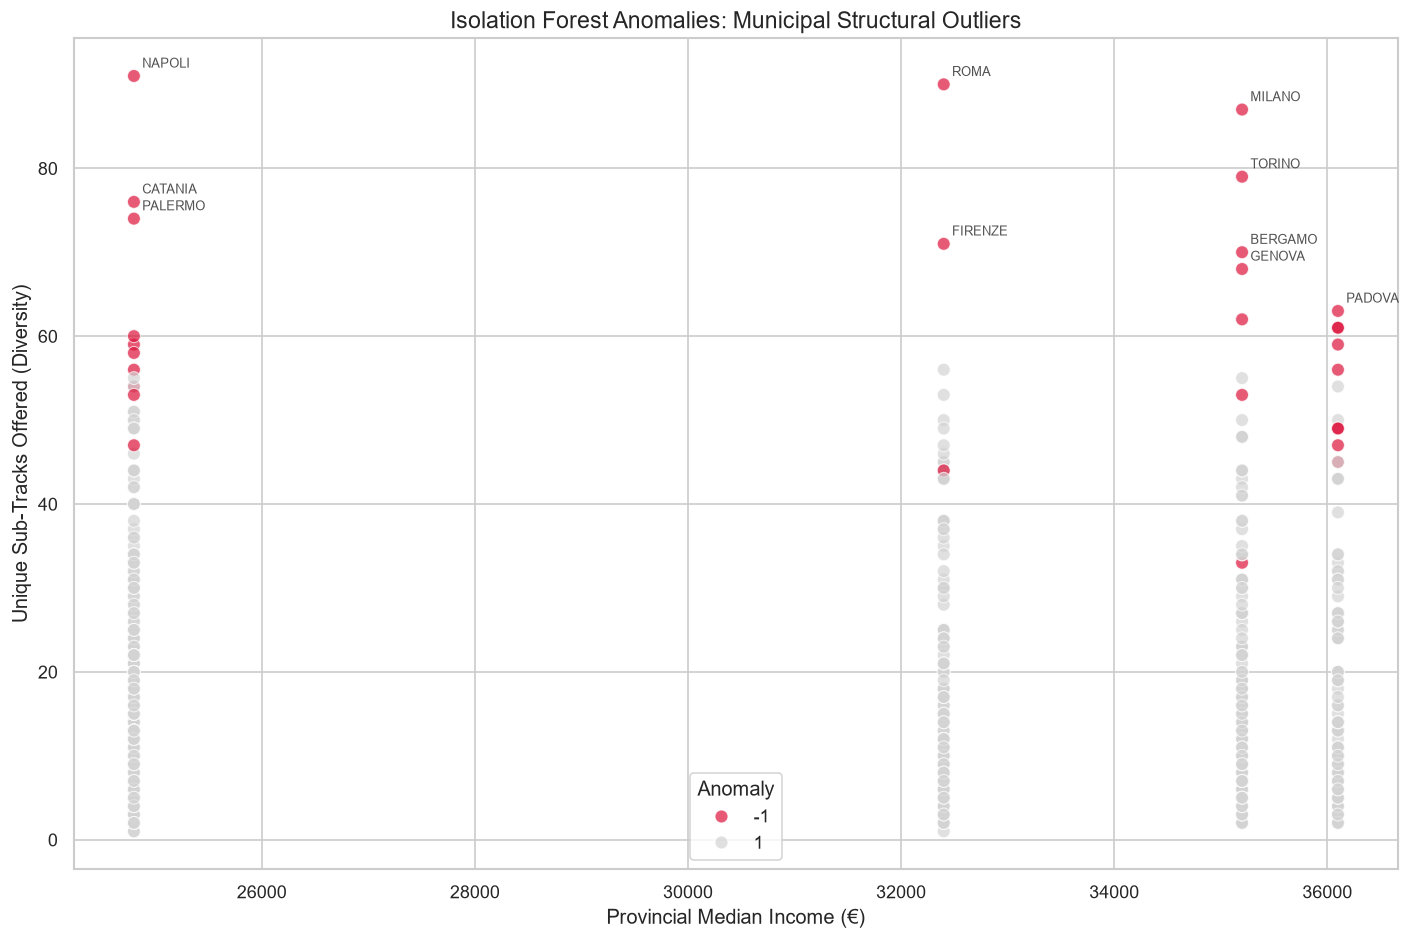

,PROVINCIA,DESCRIZIONECOMUNE,Schools,Tracks,Students,Precarity_Ratio,Median_Household_Income_EUR,Anomaly
787,NAPOLI,NAPOLI,128,91,54626,0.273743,24800.0,-1
1082,ROMA,ROMA,196,90,116738,0.406832,32400.0,-1
719,MILANO,MILANO,95,87,60673,0.675000,35200.0,-1
1245,TORINO,TORINO,90,79,42903,0.634146,35200.0,-1
305,CATANIA,CATANIA,40,76,21391,0.671875,24800.0,-1
876,PALERMO,PALERMO,64,74,34045,0.661972,24800.0,-1
461,FIRENZE,FIRENZE,45,71,23540,1.258427,32400.0,-1
158,BERGAMO,BERGAMO,28,70,18073,1.231579,35200.0,-1
524,GENOVA,GENOVA,47,68,25168,1.597015,35200.0,-1
854,PADOVA,PADOVA,38,63,19837,1.304878,36100.0,-1


In [3]:
# We build a structural matrix for municipalities
muni_stats = df.groupby(['PROVINCIA', 'DESCRIZIONECOMUNE']).agg(
    Schools=('CODICESCUOLA', 'nunique'),
    Tracks=('INDIRIZZO', 'nunique'),
    Students=('ALUNNIMASCHI', lambda x: pd.to_numeric(x, errors='coerce').sum() + pd.to_numeric(df.loc[x.index, 'ALUNNIFEMMINE'], errors='coerce').sum())
).reset_index()

muni_stats = pd.merge(muni_stats, prov_metrics[['PROVINCIA', 'Precarity_Ratio', 'Median_Household_Income_EUR']], on='PROVINCIA', how='inner')

# Filter for municipalities with at least 2 schools to find meaningful anomalies
muni_valid = muni_stats[muni_stats['Schools'] >= 2].copy()
features = ['Schools', 'Tracks', 'Students', 'Precarity_Ratio', 'Median_Household_Income_EUR']
X_muni = muni_valid[features]

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_muni)

# Isolation Forest
iso = IsolationForest(contamination=0.03, random_state=42) # Top 3% anomalies
muni_valid['Anomaly'] = iso.fit_predict(X_scaled)

# Anomalies are labeled -1
anomalies = muni_valid[muni_valid['Anomaly'] == -1]
print(f"Identified {len(anomalies)} structural anomalies out of {len(muni_valid)} municipalities.")

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=muni_valid, 
    x='Median_Household_Income_EUR', 
    y='Tracks', 
    hue='Anomaly', 
    palette={1: 'lightgrey', -1: 'crimson'}, 
    alpha=0.7, 
    s=60
)
plt.title('Isolation Forest Anomalies: Municipal Structural Outliers', fontsize=14)
plt.xlabel('Provincial Median Income (€)')
plt.ylabel('Unique Sub-Tracks Offered (Diversity)')

# Annotate a few top anomalies
for _, row in anomalies.nlargest(10, 'Tracks').iterrows():
    plt.annotate(row['DESCRIZIONECOMUNE'], (row['Median_Household_Income_EUR'], row['Tracks']), 
                 fontsize=8, alpha=0.8, xytext=(5, 5), textcoords='offset points')

plt.tight_layout()
plt.savefig(PROC / 'nb50_isolation_forest_anomalies.png')
plt.show()

display(anomalies.sort_values('Tracks', ascending=False).head(15))
